## 1. Initialize Project Environment
Import libraries for sequence analysis, clustering, and visualization.

In [1]:
from __future__ import annotations

import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("sklearn imported successfully")

pandas 2.2.3
numpy 2.1.3
sklearn imported successfully


## 2. Define Configuration Parameters
Centralize paths, clustering options, and reproducibility settings.

In [2]:
@dataclass
class ClusterConfig:
    handle: str
    fasta_path: Path = None
    export_dir: Path = Path("artifacts")
    k_values: List[int] = None
    dbscan_eps: float = 0.3
    dbscan_min_samples: int = 2
    random_state: int = 42

    def __post_init__(self):
        if self.fasta_path is None:
            self.fasta_path = Path(
                f"../../../data/work/{self.handle}/lab04/tp53_multi_sequences.fasta"
            )
        if self.k_values is None:
            self.k_values = [2, 3, 4]

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["fasta_path"] = str(info["fasta_path"])
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = ClusterConfig(handle="AndreiCod")
CONFIG.describe()

{'handle': 'AndreiCod',
 'fasta_path': '../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta',
 'export_dir': 'artifacts',
 'k_values': [2, 3, 4],
 'dbscan_eps': 0.3,
 'dbscan_min_samples': 2,
 'random_state': 42}

In [3]:
def load_sequences(cfg: ClusterConfig) -> List[SeqRecord]:
    """Load sequences from Lab 4 FASTA file."""
    if not cfg.fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {cfg.fasta_path}")

    records = list(SeqIO.parse(cfg.fasta_path, "fasta"))
    logging.info("Loaded %d sequences from %s", len(records), cfg.fasta_path)
    return records


sequences = load_sequences(CONFIG)
seq_ids = [rec.id for rec in sequences]
print(f"Loaded {len(sequences)} sequences:")
for rec in sequences:
    print(f"  {rec.id}: {len(rec.seq)} bp")

[INFO] Loaded 10 sequences from ../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta


Loaded 10 sequences:
  NM_000546.6: 2512 bp
  NM_011640.3: 1781 bp
  NM_131327.2: 2233 bp
  XM_006719566.3: 3347 bp
  NM_001317019.1: 4747 bp
  NM_001085860.1: 1719 bp
  XM_005194938.2: 5035 bp
  NM_001006919.1: 1515 bp
  NM_001089263.1: 2415 bp
  XM_031279688.1: 808 bp


## 3. Implement Core Functionality
Compute pairwise distance matrix, apply clustering methods, and evaluate quality.

In [4]:
def compute_p_distance(seq1: str, seq2: str) -> float:
    """Compute p-distance between two sequences (proportion of differing sites)."""
    min_len = min(len(seq1), len(seq2))
    if min_len == 0:
        return 1.0

    s1, s2 = seq1[:min_len], seq2[:min_len]
    differences = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return differences / min_len


def build_distance_matrix(records: List[SeqRecord]) -> Tuple[np.ndarray, List[str]]:
    """Build pairwise p-distance matrix from sequences."""
    n = len(records)
    ids = [rec.id for rec in records]
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = compute_p_distance(str(records[i].seq), str(records[j].seq))
            matrix[i, j] = dist
            matrix[j, i] = dist

    return matrix, ids


distance_matrix, seq_labels = build_distance_matrix(sequences)
logging.info("Built %dx%d distance matrix", *distance_matrix.shape)

# Display as DataFrame
dist_df = pd.DataFrame(distance_matrix, index=seq_labels, columns=seq_labels)
dist_df.round(4)

[INFO] Built 10x10 distance matrix


,NM_000546.6,NM_011640.3,NM_131327.2,XM_006719566.3,NM_001317019.1,NM_001085860.1,XM_005194938.2,NM_001006919.1,NM_001089263.1,XM_031279688.1
NM_000546.6,0.0000,0.7221,0.7528,0.7596,0.7556,0.7522,0.7528,0.7578,0.7350,0.7240
NM_011640.3,0.7221,0.0000,0.7260,0.7479,0.7339,0.7528,0.7428,0.7670,0.7653,0.7426
NM_131327.2,0.7528,0.7260,0.0000,0.7403,0.7461,0.7551,0.7532,0.7512,0.7546,0.7450
XM_006719566.3,0.7596,0.7479,0.7403,0.0000,0.7365,0.7580,0.7475,0.7366,0.7288,0.7574
NM_001317019.1,0.7556,0.7339,0.7461,0.7365,0.0000,0.7510,0.7337,0.7637,0.7441,0.7512
NM_001085860.1,0.7522,0.7528,0.7551,0.7580,0.7510,0.0000,0.7429,0.7657,0.7667,0.7760
XM_005194938.2,0.7528,0.7428,0.7532,0.7475,0.7337,0.7429,0.0000,0.7637,0.7619,0.7599
NM_001006919.1,0.7578,0.7670,0.7512,0.7366,0.7637,0.7657,0.7637,0.0000,0.7228,0.7426
NM_001089263.1,0.7350,0.7653,0.7546,0.7288,0.7441,0.7667,0.7619,0.7228,0.0000,0.7649
XM_031279688.1,0.7240,0.7426,0.7450,0.7574,0.7512,0.7760,0.7599,0.7426,0.7649,0.0000


In [5]:
def apply_hierarchical_clustering(
    distance_matrix: np.ndarray, method: str = "average"
) -> np.ndarray:
    """Apply hierarchical clustering and return linkage matrix."""
    condensed = squareform(distance_matrix)
    Z = linkage(condensed, method=method)
    return Z


linkage_matrix = apply_hierarchical_clustering(distance_matrix)
logging.info("Hierarchical clustering complete (average linkage)")

[INFO] Hierarchical clustering complete (average linkage)


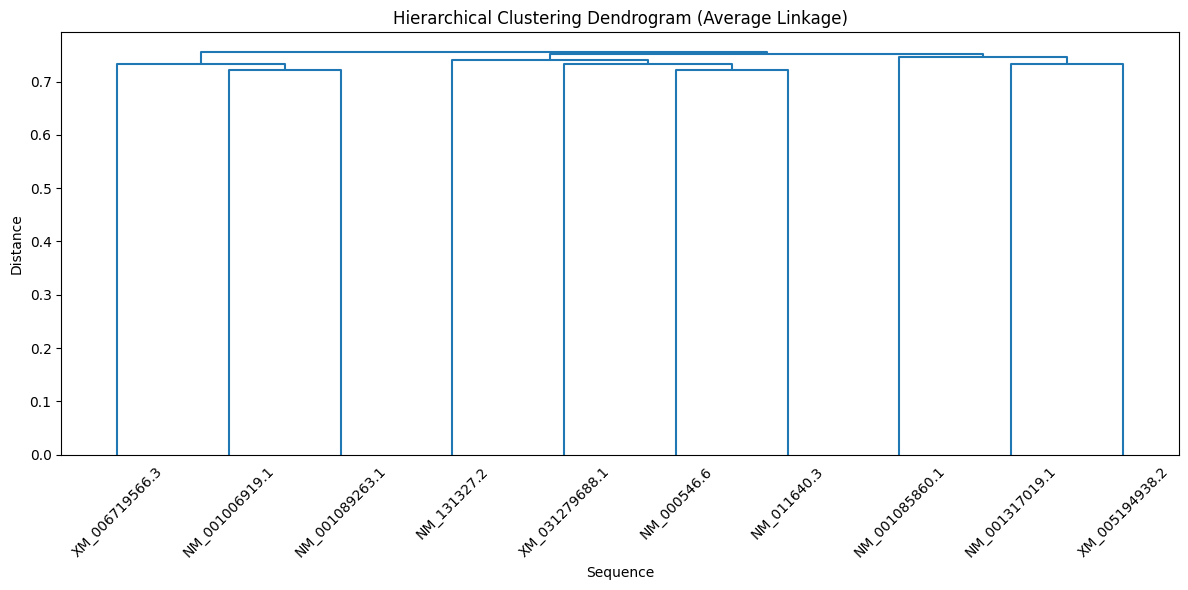

[OK] Dendrogram saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_hierarchical_dendrogram.png


In [6]:
# Visualize dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=seq_labels,
    leaf_rotation=45,
    leaf_font_size=10,
)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Sequence")
plt.ylabel("Distance")
plt.tight_layout()

# Save dendrogram
EXPORT_DIR = CONFIG.export_dir
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EXPORT_DIR / "task1_hierarchical_dendrogram.png", dpi=150)
plt.show()
print(
    f"[OK] Dendrogram saved to: {(EXPORT_DIR / 'task1_hierarchical_dendrogram.png').resolve()}"
)

In [7]:
def apply_kmeans_on_distances(
    distance_matrix: np.ndarray, k: int, random_state: int = 42
) -> np.ndarray:
    """Apply K-means clustering using MDS embedding of distance matrix."""
    from sklearn.manifold import MDS

    # Use MDS to embed distances into 2D space
    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto",
    )
    embedding = mds.fit_transform(distance_matrix)

    # Apply K-means on embedding
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(embedding)

    return labels, embedding


# Test K-means with different K values
kmeans_results = {}
for k in CONFIG.k_values:
    labels, embedding = apply_kmeans_on_distances(
        distance_matrix, k, CONFIG.random_state
    )

    # Silhouette score (only valid for k >= 2 and k < n_samples)
    if k >= 2 and k < len(sequences):
        sil_score = silhouette_score(distance_matrix, labels, metric="precomputed")
    else:
        sil_score = None

    kmeans_results[k] = {
        "labels": labels,
        "embedding": embedding,
        "silhouette": sil_score,
    }
    logging.info("K=%d: Silhouette Score = %.4f", k, sil_score if sil_score else 0)

# Select best K based on silhouette
best_k = max(
    [k for k in kmeans_results if kmeans_results[k]["silhouette"] is not None],
    key=lambda k: kmeans_results[k]["silhouette"],
)
print(f"\nBest K={best_k} with Silhouette={kmeans_results[best_k]['silhouette']:.4f}")

[INFO] K=2: Silhouette Score = 0.0096
[INFO] K=3: Silhouette Score = 0.0028
[INFO] K=4: Silhouette Score = 0.0078



Best K=2 with Silhouette=0.0096


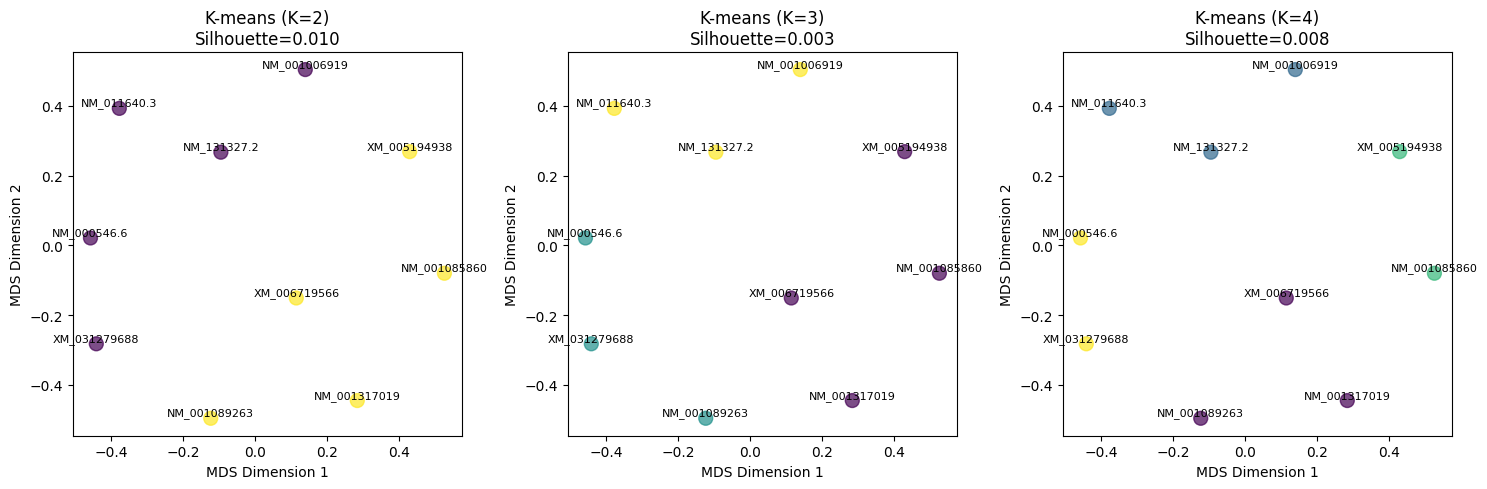

[OK] K-means plot saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_kmeans_comparison.png


In [8]:
# Visualize K-means results for best K
fig, axes = plt.subplots(1, len(CONFIG.k_values), figsize=(15, 5))

for idx, k in enumerate(CONFIG.k_values):
    ax = axes[idx]
    result = kmeans_results[k]
    embedding = result["embedding"]
    labels = result["labels"]
    sil = result["silhouette"]

    scatter = ax.scatter(
        embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", s=100, alpha=0.7
    )

    # Add sequence labels
    for i, label in enumerate(seq_labels):
        short_label = label.split()[0][:12]  # Truncate long IDs
        ax.annotate(
            short_label,
            (embedding[i, 0], embedding[i, 1]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_title(
        f"K-means (K={k})\nSilhouette={sil:.3f}" if sil else f"K-means (K={k})"
    )
    ax.set_xlabel("MDS Dimension 1")
    ax.set_ylabel("MDS Dimension 2")

plt.tight_layout()
plt.savefig(EXPORT_DIR / "task1_kmeans_comparison.png", dpi=150)
plt.show()
print(
    f"[OK] K-means plot saved to: {(EXPORT_DIR / 'task1_kmeans_comparison.png').resolve()}"
)

In [9]:
def apply_dbscan_on_distances(
    distance_matrix: np.ndarray, eps: float, min_samples: int
) -> np.ndarray:
    """Apply DBSCAN clustering on distance matrix."""
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="precomputed")
    labels = dbscan.fit_predict(distance_matrix)
    return labels


# Test multiple eps values
eps_values = [0.2, 0.3, 0.4, 0.5]
dbscan_results = {}

for eps in eps_values:
    labels = apply_dbscan_on_distances(distance_matrix, eps, CONFIG.dbscan_min_samples)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Silhouette score (only if more than 1 cluster and not all noise)
    valid_labels = labels[labels != -1]
    if n_clusters >= 2 and len(valid_labels) >= 2:
        valid_idx = labels != -1
        valid_dist = distance_matrix[valid_idx][:, valid_idx]
        sil_score = silhouette_score(
            valid_dist, labels[valid_idx], metric="precomputed"
        )
    else:
        sil_score = None

    dbscan_results[eps] = {
        "labels": labels,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": sil_score,
    }
    logging.info(
        "eps=%.2f: %d clusters, %d noise, Silhouette=%s",
        eps,
        n_clusters,
        n_noise,
        f"{sil_score:.4f}" if sil_score else "N/A",
    )

# Summary table
dbscan_summary = pd.DataFrame(
    [
        {"eps": eps, **{k: v for k, v in r.items() if k != "labels"}}
        for eps, r in dbscan_results.items()
    ]
)
dbscan_summary

[INFO] eps=0.20: 0 clusters, 10 noise, Silhouette=N/A
[INFO] eps=0.30: 0 clusters, 10 noise, Silhouette=N/A
[INFO] eps=0.40: 0 clusters, 10 noise, Silhouette=N/A
[INFO] eps=0.50: 0 clusters, 10 noise, Silhouette=N/A


,eps,n_clusters,n_noise,silhouette
0,0.2,0,10,None
1,0.3,0,10,None
2,0.4,0,10,None
3,0.5,0,10,None


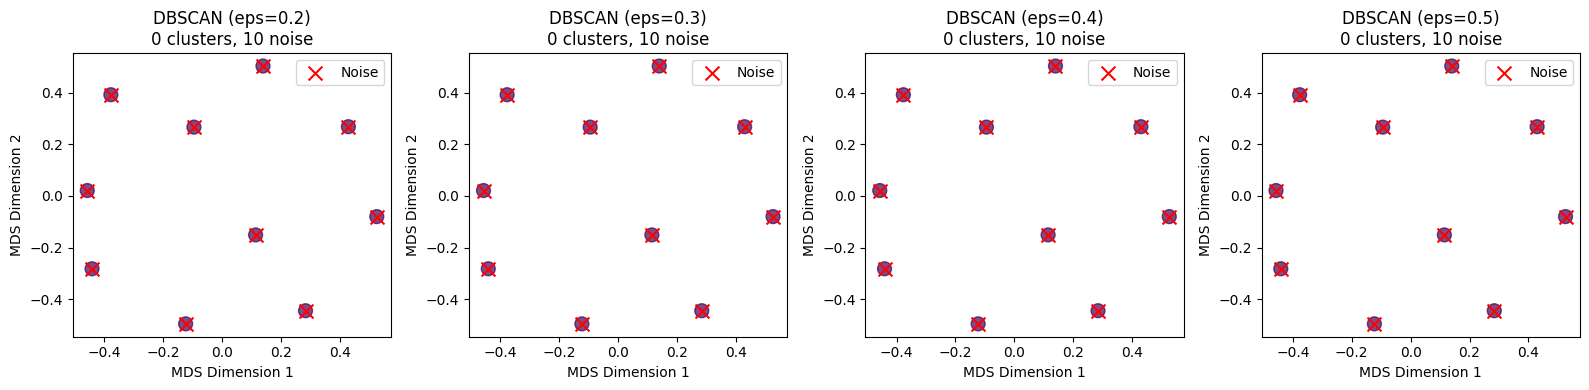

[OK] DBSCAN plot saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_dbscan_comparison.png


In [10]:
# Visualize DBSCAN results
# Use MDS embedding from best K-means
embedding = kmeans_results[best_k]["embedding"]

fig, axes = plt.subplots(1, len(eps_values), figsize=(16, 4))

for idx, eps in enumerate(eps_values):
    ax = axes[idx]
    result = dbscan_results[eps]
    labels = result["labels"]

    scatter = ax.scatter(
        embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", s=100, alpha=0.7
    )

    # Mark noise points
    noise_mask = labels == -1
    ax.scatter(
        embedding[noise_mask, 0],
        embedding[noise_mask, 1],
        c="red",
        marker="x",
        s=100,
        label="Noise",
    )

    ax.set_title(
        f"DBSCAN (eps={eps})\n{result['n_clusters']} clusters, {result['n_noise']} noise"
    )
    ax.set_xlabel("MDS Dimension 1")
    ax.set_ylabel("MDS Dimension 2")
    if noise_mask.any():
        ax.legend()

plt.tight_layout()
plt.savefig(EXPORT_DIR / "task1_dbscan_comparison.png", dpi=150)
plt.show()
print(
    f"[OK] DBSCAN plot saved to: {(EXPORT_DIR / 'task1_dbscan_comparison.png').resolve()}"
)

## 4. Validate with Unit Tests
Quick checks to ensure distance computation and clustering behave correctly.

In [11]:
def test_p_distance():
    assert compute_p_distance("AAAA", "AAAA") == 0.0
    assert compute_p_distance("AAAA", "TTTT") == 1.0
    assert compute_p_distance("AAAA", "AATT") == 0.5
    # Different lengths should truncate
    assert compute_p_distance("AAAA", "AA") == 0.0


def test_distance_matrix_symmetric():
    assert np.allclose(distance_matrix, distance_matrix.T)
    assert np.allclose(np.diag(distance_matrix), 0)


def test_clustering_labels_shape():
    for k, result in kmeans_results.items():
        assert len(result["labels"]) == len(sequences)


test_p_distance()
test_distance_matrix_symmetric()
test_clustering_labels_shape()
print("All unit tests passed.")

All unit tests passed.


## 5. Export Results
Save clustering labels, quality metrics, and distance matrix to artifacts.

In [12]:
# Create comprehensive results DataFrame
results_df = pd.DataFrame({"sequence_id": seq_labels})

# Add hierarchical clusters at different cut heights
for n_clusters in [2, 3]:
    hc_labels = fcluster(linkage_matrix, n_clusters, criterion="maxclust")
    results_df[f"Hierarchical_K{n_clusters}"] = hc_labels

# Add K-means results
for k, result in kmeans_results.items():
    results_df[f"KMeans_K{k}"] = result["labels"]

# Add best DBSCAN result
best_eps = 0.3  # Default reasonable choice
results_df[f"DBSCAN_eps{best_eps}"] = dbscan_results[best_eps]["labels"]

results_df

,sequence_id,Hierarchical_K2,Hierarchical_K3,KMeans_K2,KMeans_K3,KMeans_K4,DBSCAN_eps0.3
0,NM_000546.6,2,2,0,1,3,-1
1,NM_011640.3,2,2,0,2,1,-1
2,NM_131327.2,2,2,0,2,1,-1
3,XM_006719566.3,1,1,1,0,0,-1
4,NM_001317019.1,2,3,1,0,0,-1
5,NM_001085860.1,2,3,1,0,2,-1
6,XM_005194938.2,2,3,1,0,2,-1
7,NM_001006919.1,1,1,0,2,1,-1
8,NM_001089263.1,1,1,1,1,0,-1
9,XM_031279688.1,2,2,0,1,3,-1


In [13]:
# Save all artifacts
import json

# 1. Cluster labels
results_path = EXPORT_DIR / "task1_cluster_labels.csv"
results_df.to_csv(results_path, index=False)
print(f"[OK] Cluster labels saved to: {results_path.resolve()}")

# 2. Distance matrix
dist_path = EXPORT_DIR / "task1_distance_matrix.csv"
dist_df.to_csv(dist_path)
print(f"[OK] Distance matrix saved to: {dist_path.resolve()}")

# 3. Quality metrics
quality_metrics = {
    "kmeans": {
        str(k): {"silhouette": r["silhouette"]} for k, r in kmeans_results.items()
    },
    "dbscan": {
        str(eps): {
            "n_clusters": r["n_clusters"],
            "n_noise": r["n_noise"],
            "silhouette": r["silhouette"],
        }
        for eps, r in dbscan_results.items()
    },
    "best_kmeans_k": best_k,
    "best_kmeans_silhouette": kmeans_results[best_k]["silhouette"],
}

metrics_path = EXPORT_DIR / "task1_quality_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(quality_metrics, f, indent=2)
print(f"[OK] Quality metrics saved to: {metrics_path.resolve()}")

print(f"\nAll Task 1 artifacts saved to {EXPORT_DIR.resolve()}")

[OK] Cluster labels saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_cluster_labels.csv
[OK] Distance matrix saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_distance_matrix.csv
[OK] Quality metrics saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_quality_metrics.json

All Task 1 artifacts saved to /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts
